Thesis Figures — Index\n\nThis folder contains **5 focused notebooks**, one per figure type.\nRun each notebook independently — all are self-contained.\n\nAll figures are saved to `data/thesis_figures/comparison/` at 300 DPI.\n\n| Notebook | Output prefix | What it shows |\n|---|---|---|\n| `fig1_grid.ipynb` | `fig1_grid__*` | Retrieval quality: Random vs Pretrained vs Fine-tuned (top) vs Fine-tuned (bottom) |\n| `fig2_distributions.ipynb` | `fig2_dist__*` | Score density: how well each model discriminates compatible items |\n| `fig3_refinement.ipynb` | `fig3_refine__*` | Progressive refinement: distributions narrow as more context is added |\n| `fig4_chain.ipynb` | `fig4_chain__*` | Full room construction chain step-by-step (chaining as in the app) |\n| `fig5_weights.ipynb` | `fig5_weights__*` | Same furniture, embed=1.0 vs embed=0.5 / hist=0.5, for both rooms |\n\n---\n\n**Quick-start**: open `fig4_chain.ipynb` to see the selection chain, or `fig5_weights.ipynb` to compare weight settings.

In [1]:
import sys
from pathlib import Path
from scipy.stats import gaussian_kde

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from PIL import Image
import torch
import torchvision.models as models
import torchvision.transforms as T

# ── Project root ─────────────────────────────────────────────────────────────
BASE_DIR = next(
    p for p in [Path().cwd()] + list(Path().cwd().parents)
    if (p / "src" / "retrieval" / "retrieval_logic.py").exists()
)
sys.path.insert(0, str(BASE_DIR / "src" / "retrieval"))
from retrieval_logic import FurnitureRetriever, CATEGORY_CHAINS

OUT_DIR = BASE_DIR / "data" / "thesis_figures" / "comparison"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Typography & style ────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "DejaVu Serif",
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.titleweight":  "bold",
    "axes.labelsize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#E0E0E0",
    "grid.linewidth":    0.5,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "savefig.facecolor": "white",
})

# ── Colour palette (one colour per retrieval method) ─────────────────────────
# bg  = header background
# fg  = text / dark accent
# line = curve / border colour
PAL = {
    "random":     {"bg": "#F5F5F5", "fg": "#424242", "line": "#9E9E9E"},
    "pretrained": {"bg": "#E3F2FD", "fg": "#0D47A1", "line": "#1565C0"},
    "trained":    {"bg": "#E8F5E9", "fg": "#1B5E20", "line": "#2E7D32"},
    "worst":      {"bg": "#FFEBEE", "fg": "#B71C1C", "line": "#C62828"},
}

STEP_LABELS = {
    "bed": "Bed", "sofa": "Sofa",
    "small_storage": "Storage", "large_storage": "Storage",
    "table": "Table", "chair_stool": "Chair / Stool", "curtain": "Curtain",
}

def cat_label(cat: str) -> str:
    return STEP_LABELS.get(cat, cat)

def open_img(path) -> Image.Image:
    return Image.open(path).convert("RGB")

print(f"BASE_DIR : {BASE_DIR}")
print(f"Output   : {OUT_DIR}")

BASE_DIR : d:\Programing\thesis_v2_v3
Output   : d:\Programing\thesis_v2_v3\data\thesis_figures\comparison


In [2]:
# ── Room selection ────────────────────────────────────────────────────────────
ROOM = "bedrooms"   # ← change to "living_rooms" if needed

retriever = FurnitureRetriever(room=ROOM, embed_weight=1.0, hist_weight=0.0)
chain     = CATEGORY_CHAINS[ROOM]

print(f"Room : {ROOM}")
print(f"Chain: {chain}")
print(f"Steps: {[cat_label(c) for c in chain]}")

Loading histogram cache...
FurnitureRetriever ready — 2662 items, 6 categories
  bed            : 553 items
  chair_stool    : 357 items
  curtain        : 431 items
  large_storage  : 368 items
  small_storage  : 636 items
  table          : 317 items
Room : bedrooms
Chain: ['bed', 'small_storage', 'large_storage', 'table', 'chair_stool', 'curtain']
Steps: ['Bed', 'Storage', 'Storage', 'Table', 'Chair / Stool', 'Curtain']


In [3]:
# ── Pretrained ResNet-18 embeddings (cached after first run ~1 min) ───────────
cache_path = BASE_DIR / "data" / "retrieval_data" / ROOM / "pretrained_resnet18_embeddings.npz"

if cache_path.exists():
    print("Loading cached pretrained embeddings…")
    pretrained_embs = np.load(cache_path, allow_pickle=False)["embeddings"]
else:
    print("Computing pretrained ResNet-18 embeddings (one-time, ~1 min)…")
    backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    backbone.fc = torch.nn.Identity()   # 512-d features
    backbone.eval()
    transform = T.Compose([
        T.Resize(256), T.CenterCrop(224), T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    N = len(retriever._index)
    pretrained_embs = np.zeros((N, 512), dtype=np.float32)
    with torch.no_grad():
        for row, meta in retriever._index.items():
            p = retriever.image_root / meta["category"] / meta["image_name"]
            if p.exists():
                t   = transform(open_img(p)).unsqueeze(0)
                vec = backbone(t).squeeze().numpy()
                n   = np.linalg.norm(vec)
                pretrained_embs[row] = vec / n if n > 0 else vec
    np.savez_compressed(cache_path, embeddings=pretrained_embs)
    print(f"Saved → {cache_path}")

print(f"Shape: {pretrained_embs.shape}")

Loading cached pretrained embeddings…
Shape: (2662, 512)


In [4]:
# ── Retrieval helpers ─────────────────────────────────────────────────────────

def score_pretrained(anchor: dict, target_cat: str, top_k: int = 9999) -> list:
    """Rank target_cat items by cosine similarity using pretrained ResNet-18."""
    a_row  = retriever._id_to_row[anchor["furniture_id"]]
    a_emb  = pretrained_embs[a_row]
    rows   = retriever._category_rows[target_cat]
    scores = pretrained_embs[np.array(rows)] @ a_emb
    k      = min(top_k, len(scores))
    idx    = np.argpartition(scores, -k)[-k:]
    idx    = idx[np.argsort(scores[idx])[::-1]]
    return [
        retriever._to_dict(rows[i], score=float(scores[i]),
                           embed_score=float(scores[i]), hist_score=0.0)
        for i in idx
    ]


def get_all_rankings(anchor: dict, target_cat: str, n: int = 3) -> dict:
    """Return top-n results per method plus full ranked lists."""
    trained_all    = retriever.get_compatible([anchor], target_cat, top_k=9999)
    pretrained_all = score_pretrained(anchor, target_cat)
    return {
        "random":          retriever.get_random(target_cat, n=n),
        "pretrained":      pretrained_all[:n],
        "trained":         trained_all[:n],
        "worst":           list(reversed(trained_all[-n:])),
        "_trained_all":    trained_all,
        "_pretrained_all": pretrained_all,
    }


print("Helpers ready.")

Helpers ready.


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 1 — Retrieval Comparison Grid
# Layout: anchor image (left) | 4 method columns × n rows of results
# ─────────────────────────────────────────────────────────────────────────────

COL_META = [
    ("random",     "Random",               "No model — blind pick"),
    ("pretrained", "Pretrained\nResNet-18", "ImageNet features, no fine-tuning"),
    ("trained",    "Fine-tuned\nResNet-18", "Trained for compatibility (top-ranked)"),
    ("worst",      "Fine-tuned\nResNet-18", "Trained for compatibility (worst-ranked)"),
]


def make_grid_figure(anchor: dict, target_cat: str, n: int = 3) -> plt.Figure:
    """
    Figure 1: side-by-side comparison of 4 retrieval strategies.

    Each image cell is ~1.9 inches so furniture details are visible at 300 DPI.
    Scores are shown below each image for methods that produce them.
    """
    rankings = get_all_rankings(anchor, target_cat, n=n)

    CELL   = 1.9          # inches per image cell
    ANCHOR = CELL * 1.25  # anchor column slightly wider
    n_cols = len(COL_META)

    fig_w = ANCHOR + n_cols * CELL
    fig_h = CELL * n + 0.85   # rows + header row
    fig   = plt.figure(figsize=(fig_w, fig_h), dpi=150)

    gs = gridspec.GridSpec(
        n + 1, n_cols + 1,
        figure=fig,
        width_ratios=[ANCHOR / CELL] + [1.0] * n_cols,
        hspace=0.05, wspace=0.05,
        top=0.88, bottom=0.06, left=0.02, right=0.99,
    )

    anchor_lbl = cat_label(anchor["category"])
    target_lbl = cat_label(target_cat)

    # ── Main title ────────────────────────────────────────────────────────
    fig.suptitle(
        f"Retrieval Comparison: given a {anchor_lbl}, find compatible {target_lbl} items",
        fontsize=10, fontweight="bold", y=0.96,
    )

    # ── Anchor column header ──────────────────────────────────────────────
    ax_ah = fig.add_subplot(gs[0, 0])
    ax_ah.set_facecolor("#F5F5F5")
    ax_ah.text(0.5, 0.60, "Query item",
               ha="center", va="center", fontsize=8.5,
               fontweight="bold", color="#212121",
               transform=ax_ah.transAxes)
    ax_ah.text(0.5, 0.22, f"({anchor_lbl})",
               ha="center", va="center", fontsize=7.5,
               color="#616161", transform=ax_ah.transAxes)
    ax_ah.axis("off")

    # Anchor image spanning all item rows
    ax_a = fig.add_subplot(gs[1:, 0])
    ax_a.imshow(open_img(anchor["image_path"]))
    ax_a.axis("off")
    for sp in ax_a.spines.values():
        sp.set_visible(True)
        sp.set_linewidth(1.5)
        sp.set_edgecolor("#757575")

    # ── Method column headers ──────────────────────────────────────────────
    for ci, (key, name, subtitle) in enumerate(COL_META):
        p  = PAL[key]
        ax = fig.add_subplot(gs[0, ci + 1])
        ax.set_facecolor(p["bg"])
        # Top border stripe — use ax.plot (axhline does not accept transform=)
        ax.plot([0, 1], [1, 1], color=p["line"], linewidth=3,
                transform=ax.transAxes, clip_on=False, solid_capstyle="butt")
        ax.text(0.5, 0.62, name,
                ha="center", va="center", fontsize=8,
                fontweight="bold", color=p["fg"],
                transform=ax.transAxes, linespacing=1.35)
        ax.text(0.5, 0.17, subtitle,
                ha="center", va="center", fontsize=6.5,
                color=p["fg"], alpha=0.80,
                transform=ax.transAxes, linespacing=1.2)
        ax.axis("off")

    # ── Item cells ─────────────────────────────────────────────────────────
    for ci, (key, _, _) in enumerate(COL_META):
        p     = PAL[key]
        items = rankings[key]
        for ri, item in enumerate(items[:n]):
            ax = fig.add_subplot(gs[ri + 1, ci + 1])
            ax.imshow(open_img(item["image_path"]))
            ax.axis("off")
            for sp in ax.spines.values():
                sp.set_visible(True)
                sp.set_linewidth(0.9)
                sp.set_edgecolor(p["line"])

            score = item.get("score", 0.0)
            if score != 0.0:
                ax.text(0.5, -0.04, f"score: {score:.3f}",
                        ha="center", va="top", fontsize=6.5,
                        color=p["fg"], fontweight="bold",
                        transform=ax.transAxes)
            else:
                ax.text(0.5, -0.04, "(no score)",
                        ha="center", va="top", fontsize=6.5,
                        color="#9E9E9E", transform=ax.transAxes)

    # ── Footer ────────────────────────────────────────────────────────────
    fig.text(0.5, 0.01,
             f"Retrieved category: {target_lbl}  |  Shown: top {n} results per method",
             ha="center", va="bottom", fontsize=7, color="#757575")

    return fig


print("Figure 1 builder ready.")

Figure 1 builder ready.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 2 — Score Distribution: Pretrained vs Fine-tuned
# A higher, right-shifted distribution = model finds more compatible items.
# ─────────────────────────────────────────────────────────────────────────────

def make_distribution_figure(anchor: dict, target_cat: str) -> plt.Figure:
    """
    Figure 2: overlaid score density for pretrained vs fine-tuned model.

    What to read: the fine-tuned model pushes compatible items toward score 1.0,
    producing a higher mean and a narrower peak — better discrimination.
    """
    rankings    = get_all_rankings(anchor, target_cat)
    s_pre       = np.array([r["score"] for r in rankings["_pretrained_all"]])
    s_train     = np.array([r["score"] for r in rankings["_trained_all"]])
    anchor_lbl  = cat_label(anchor["category"])
    target_lbl  = cat_label(target_cat)

    fig, ax = plt.subplots(figsize=(6.5, 4.0))

    x_min = min(s_pre.min(), s_train.min()) - 0.01
    x_max = max(s_pre.max(), s_train.max()) + 0.01
    bins  = np.linspace(x_min, x_max, 50)

    # ── Histograms (light fill for context) ───────────────────────────────
    ax.hist(s_pre,   bins=bins, density=True, alpha=0.25,
            color=PAL["pretrained"]["line"], zorder=2)
    ax.hist(s_train, bins=bins, density=True, alpha=0.25,
            color=PAL["trained"]["line"],    zorder=2)

    # ── KDE curves ────────────────────────────────────────────────────────
    xs = np.linspace(x_min, x_max, 400)
    for scores, key, label in [
        (s_pre,   "pretrained", "Pretrained ResNet-18  (ImageNet, no fine-tuning)"),
        (s_train, "trained",    "Fine-tuned ResNet-18  (trained for compatibility)"),
    ]:
        kde = gaussian_kde(scores, bw_method=0.25)
        ys  = kde(xs)
        ax.plot(xs, ys, lw=2.0, color=PAL[key]["line"], label=label, zorder=3)

        # Mean vline — use get_xaxis_transform so y is in axes fraction
        ax.axvline(scores.mean(), lw=1.2, ls="--",
                   color=PAL[key]["line"], alpha=0.85, zorder=4)
        ax.text(
            scores.mean(), 0.97,
            f" μ = {scores.mean():.3f}",
            ha="left", va="top", fontsize=7.5,
            color=PAL[key]["fg"], fontweight="bold",
            transform=ax.get_xaxis_transform(),   # x=data, y=axes fraction
            zorder=5,
        )

    # ── Axes labels ───────────────────────────────────────────────────────
    ax.set_xlabel("Compatibility score  (0 = unrelated,  1 = perfect match)", labelpad=5)
    ax.set_ylabel("Probability density", labelpad=5)
    ax.set_title(
        f"Score Distributions — {anchor_lbl} → {target_lbl}",
        pad=8,
    )
    ax.set_xlim(x_min, x_max)
    ax.yaxis.set_major_locator(MaxNLocator(4, prune="both"))
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.legend(loc="upper left", framealpha=0.95, edgecolor="#CCCCCC")

    # ── Stats annotation box ──────────────────────────────────────────────
    stats_lines = [
        f"{'':14s}  {'Pretrained':>11s}  {'Fine-tuned':>10s}",
        f"{'Mean':14s}  {s_pre.mean():>11.3f}  {s_train.mean():>10.3f}",
        f"{'Std':14s}  {s_pre.std():>11.3f}  {s_train.std():>10.3f}",
        f"{'Top-5 threshold':14s}  {np.sort(s_pre)[-5]:>11.3f}  {np.sort(s_train)[-5]:>10.3f}",
    ]
    ax.text(
        0.97, 0.97, "\n".join(stats_lines),
        ha="right", va="top", fontsize=7,
        family="monospace",
        transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#CCCCCC", linewidth=0.8),
    )

    n_cand = len(s_train)
    fig.text(0.5, 0.01,
             f"{n_cand} candidate {target_lbl} items scored",
             ha="center", va="bottom", fontsize=7.5, color="#757575")

    fig.tight_layout(rect=[0, 0.03, 1, 1])
    return fig


print("Figure 2 builder ready.")

Figure 2 builder ready.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure 3 — Progressive Refinement
# Shows how the score distribution for a target category narrows and shifts
# as more previously selected items are used as context.
# ─────────────────────────────────────────────────────────────────────────────

# Colours for k=1,2,3 context items: light → medium → dark
REFINE_COLORS = ["#90CAF9", "#1976D2", "#0D47A1"]   # blue progression
REFINE_ALPHAS = [0.30, 0.30, 0.30]                   # histogram fill opacity


def build_refinement_scenario(
    target_idx: int,
    seed: int = 0,
) -> tuple[list[dict], str, list[tuple[str, np.ndarray]]]:
    """
    Build context items and compute score distributions for increasing context sizes.

    target_idx must be >= 2 to show at least 2 curves (k=1 and k=2).
    Returns: (anchors, target_cat, [(label, scores), ...])
    """
    assert target_idx >= 2, "target_idx must be >= 2"
    rng     = np.random.default_rng(seed)
    anchors: list[dict] = []

    for cat in chain[:target_idx]:
        if anchors:
            pool = retriever.get_compatible(
                selected=anchors, target_category=cat, top_k=30
            )
            anchors.append(pool[rng.integers(len(pool))])
        else:
            anchors.append(retriever.get_random(cat, n=1)[0])

    target_cat  = chain[target_idx]
    n_cand      = len(retriever._category_rows[target_cat])
    dists: list[tuple[str, np.ndarray]] = []

    for k in range(1, len(anchors) + 1):
        context = anchors[:k]
        results = retriever.get_compatible(
            selected=context, target_category=target_cat, top_k=n_cand
        )
        scores = np.array([r["score"] for r in results])
        ctx_names = " + ".join(cat_label(a["category"]) for a in context)
        label = f"{k} item{'s' if k > 1 else ''}  ({ctx_names})"
        dists.append((label, scores))

    return anchors, target_cat, dists


def make_refinement_figure(
    target_idx: int = 3,
    seed: int = 0,
) -> plt.Figure:
    """
    Figure 3: how score distributions change as context grows.

    target_idx=3 means target is chain[3]; context comes from chain[0..2].
    The key thesis message: with more context, the model becomes more
    selective — the distribution shifts right and narrows.
    """
    anchors, target_cat, dists = build_refinement_scenario(target_idx, seed)
    target_lbl = cat_label(target_cat)

    # Use only up to 3 curves (more is visually cluttered)
    dists = dists[:3]
    colors = REFINE_COLORS[:len(dists)]
    alphas = REFINE_ALPHAS[:len(dists)]

    fig, ax = plt.subplots(figsize=(7.0, 4.2))

    all_scores = np.concatenate([s for _, s in dists])
    x_min = all_scores.min() - 0.01
    x_max = all_scores.max() + 0.01
    bins  = np.linspace(x_min, x_max, 50)
    xs    = np.linspace(x_min, x_max, 400)

    for (label, scores), color, alpha in zip(dists, colors, alphas):
        ax.hist(scores, bins=bins, density=True,
                alpha=alpha, color=color, zorder=2)

        kde = gaussian_kde(scores, bw_method=0.25)
        ys  = kde(xs)
        ax.plot(xs, ys, lw=2.0, color=color, label=label, zorder=3)

        # Mean vline
        ax.axvline(scores.mean(), lw=1.0, ls=":",
                   color=color, alpha=0.9, zorder=4)

    ax.set_xlabel("Compatibility score  (0 = unrelated,  1 = perfect match)", labelpad=5)
    ax.set_ylabel("Probability density", labelpad=5)
    ax.set_title(
        f"Progressive Refinement — Scoring {target_lbl} with Increasing Context",
        pad=8,
    )
    ax.set_xlim(x_min, x_max)
    ax.yaxis.set_major_locator(MaxNLocator(4, prune="both"))
    ax.xaxis.set_major_locator(MaxNLocator(6))
    ax.legend(
        title="Context (items already selected)",
        title_fontsize=7.5,
        loc="upper left",
        framealpha=0.95, edgecolor="#CCCCCC",
    )

    # Stats table (mean per curve)
    stats_lines = [f"{'Context':30s}  {'Mean':>6s}  {'Std':>6s}"]
    for (label, scores), color in zip(dists, colors):
        short = label.split("  ")[0]   # "1 item" / "2 items" / "3 items"
        stats_lines.append(f"{short:30s}  {scores.mean():>6.3f}  {scores.std():>6.3f}")

    ax.text(
        0.97, 0.97, "\n".join(stats_lines),
        ha="right", va="top", fontsize=7,
        family="monospace", transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                  edgecolor="#CCCCCC", linewidth=0.8),
    )

    n_cand = len(dists[0][1])
    fig.text(
        0.5, 0.01,
        f"{n_cand} candidate {target_lbl} items scored  |  "
        f"Dotted lines = mean score per context",
        ha="center", va="bottom", fontsize=7.5, color="#757575",
    )

    fig.tight_layout(rect=[0, 0.03, 1, 1])
    return fig


print("Figure 3 builder ready.")

Figure 3 builder ready.



Bed → Storage


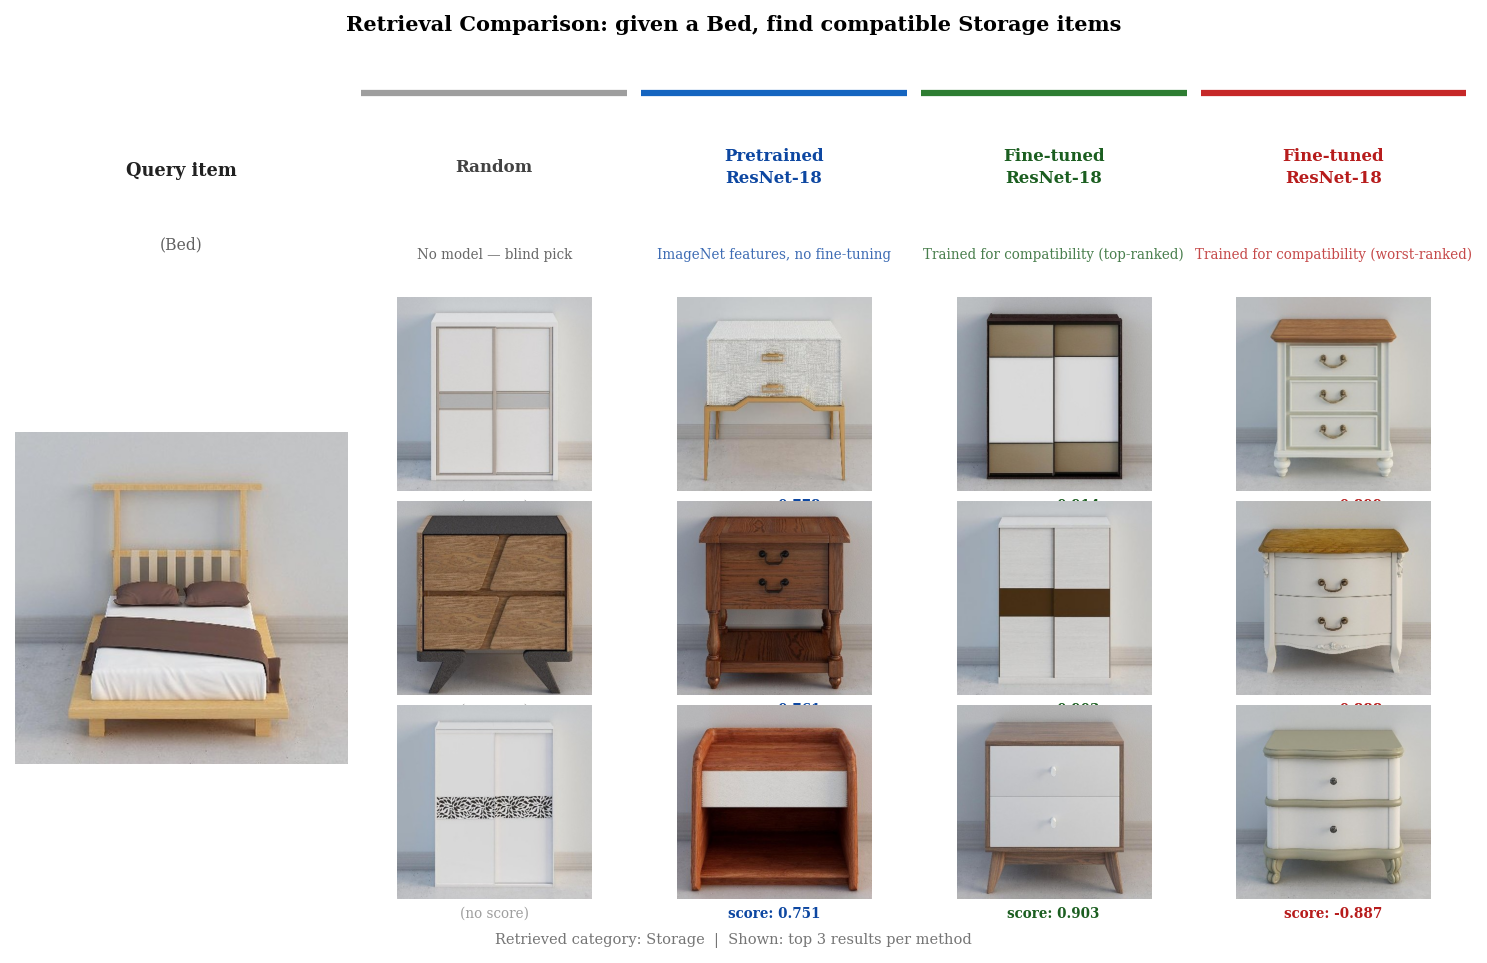

  Saved: fig1_grid__bedrooms__Bed__to__Storage.png


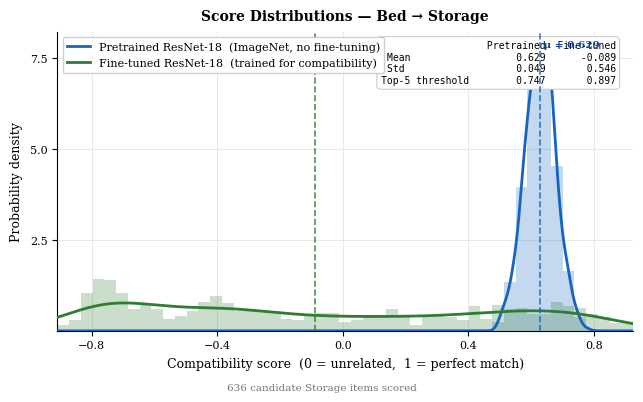

  Saved: fig2_dist__bedrooms__Bed__to__Storage.png

Bed → Storage


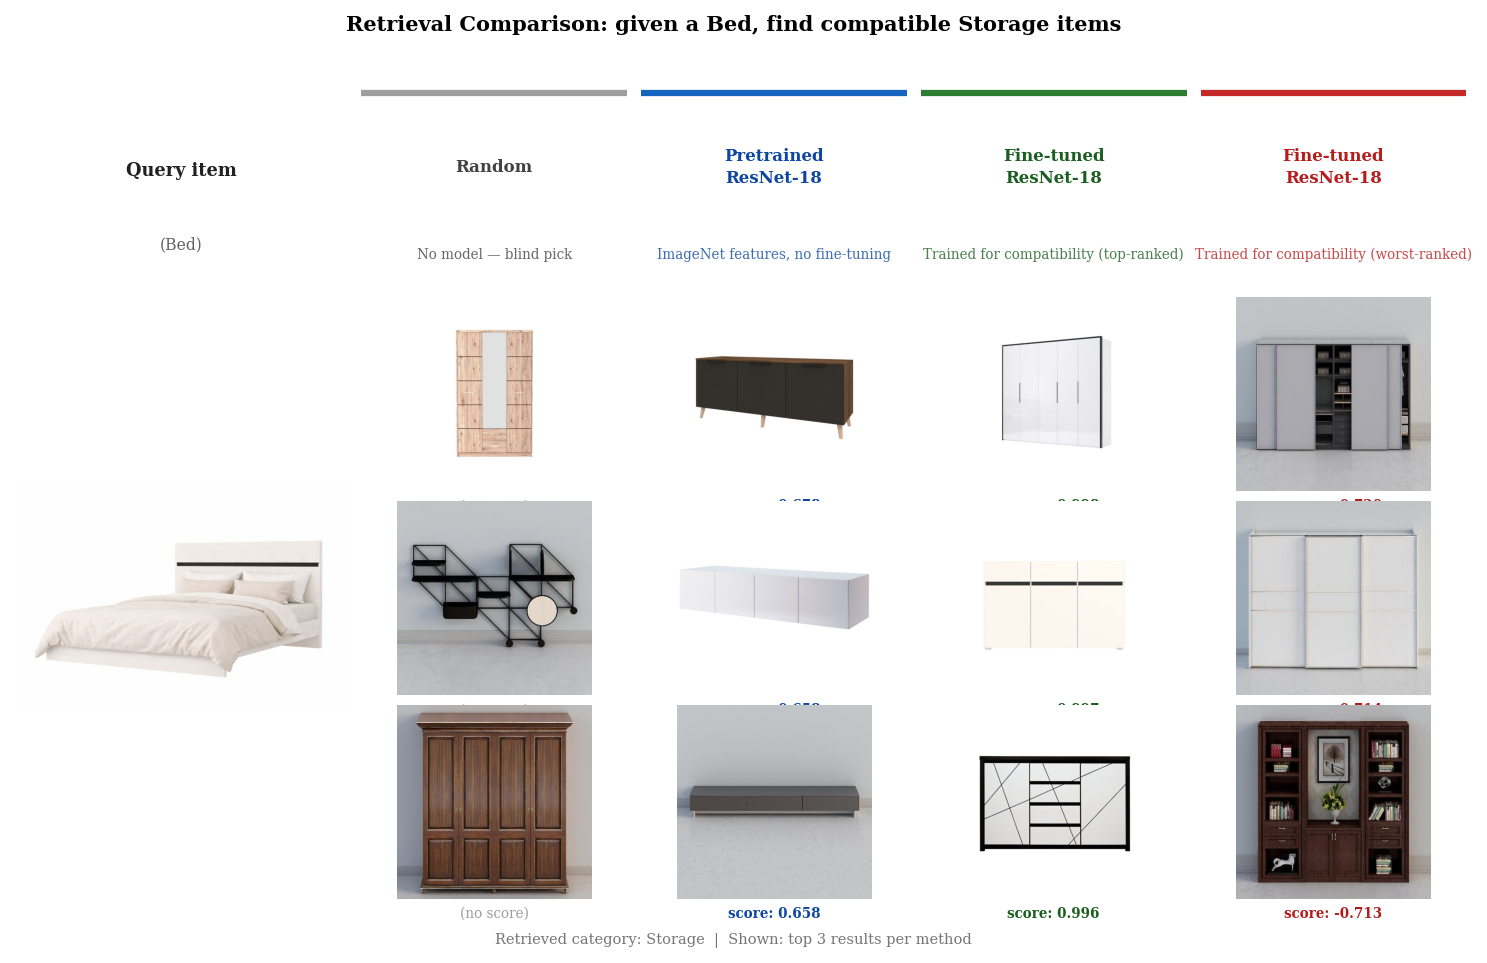

  Saved: fig1_grid__bedrooms__Bed__to__Storage.png


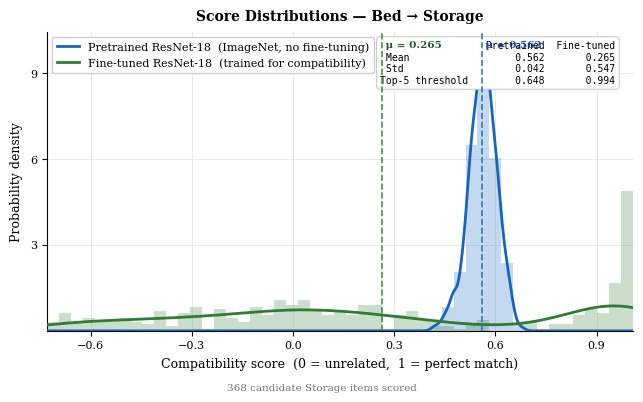

  Saved: fig2_dist__bedrooms__Bed__to__Storage.png

Storage → Table


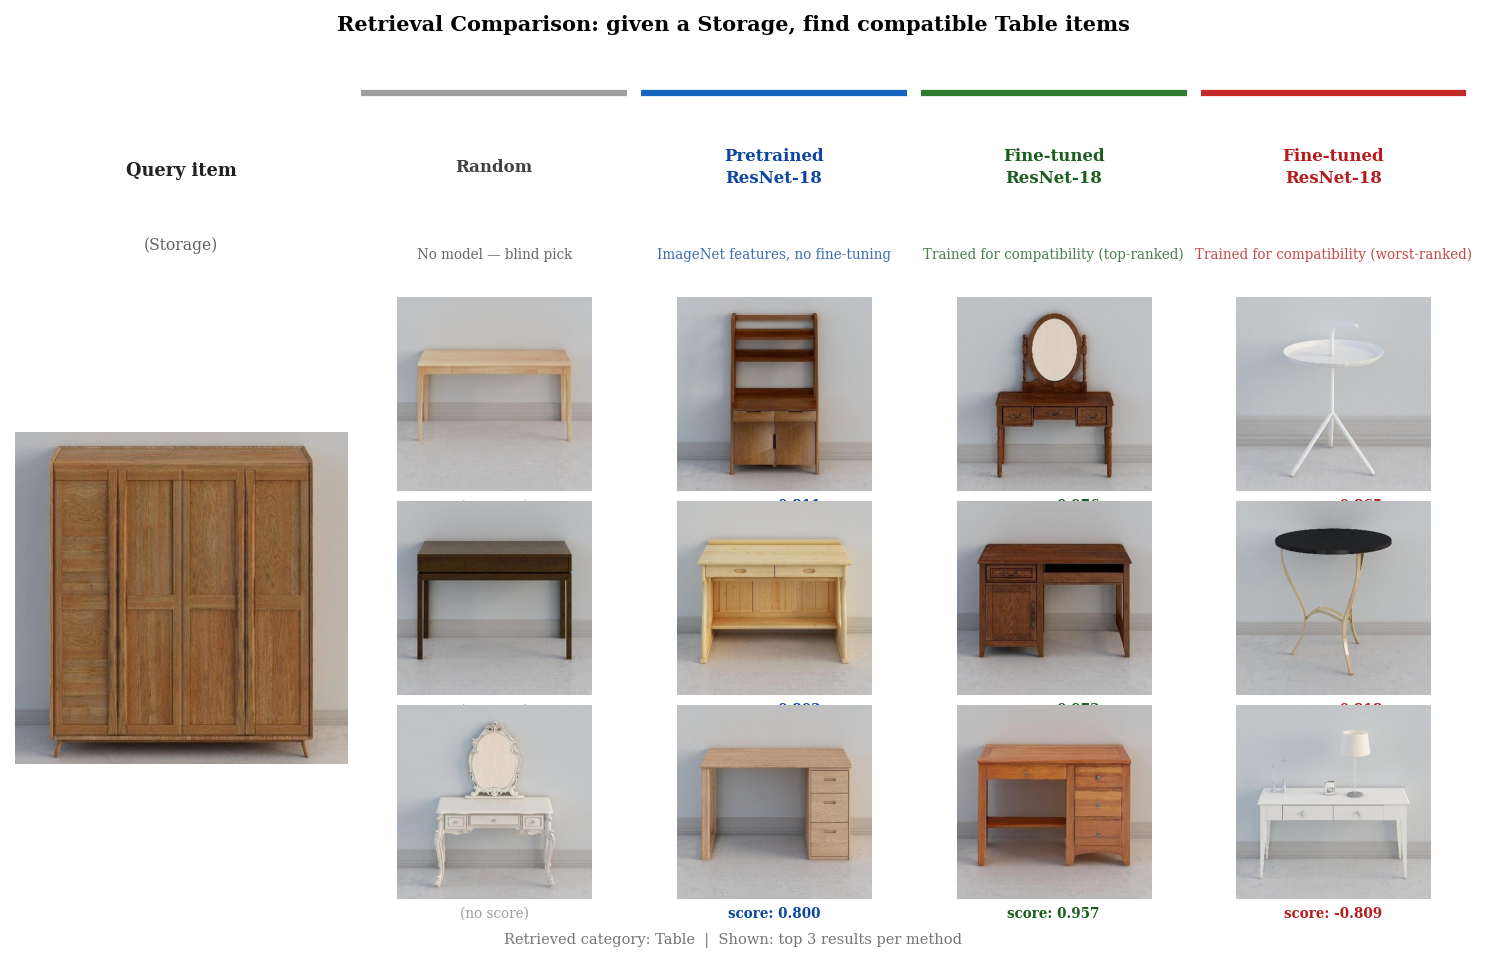

  Saved: fig1_grid__bedrooms__Storage__to__Table.png


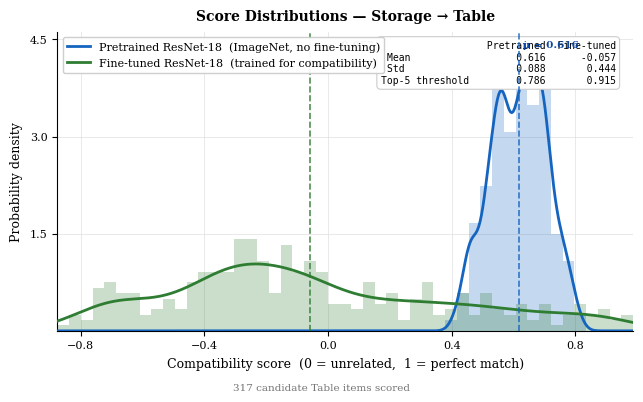

  Saved: fig2_dist__bedrooms__Storage__to__Table.png

Table → Chair / Stool


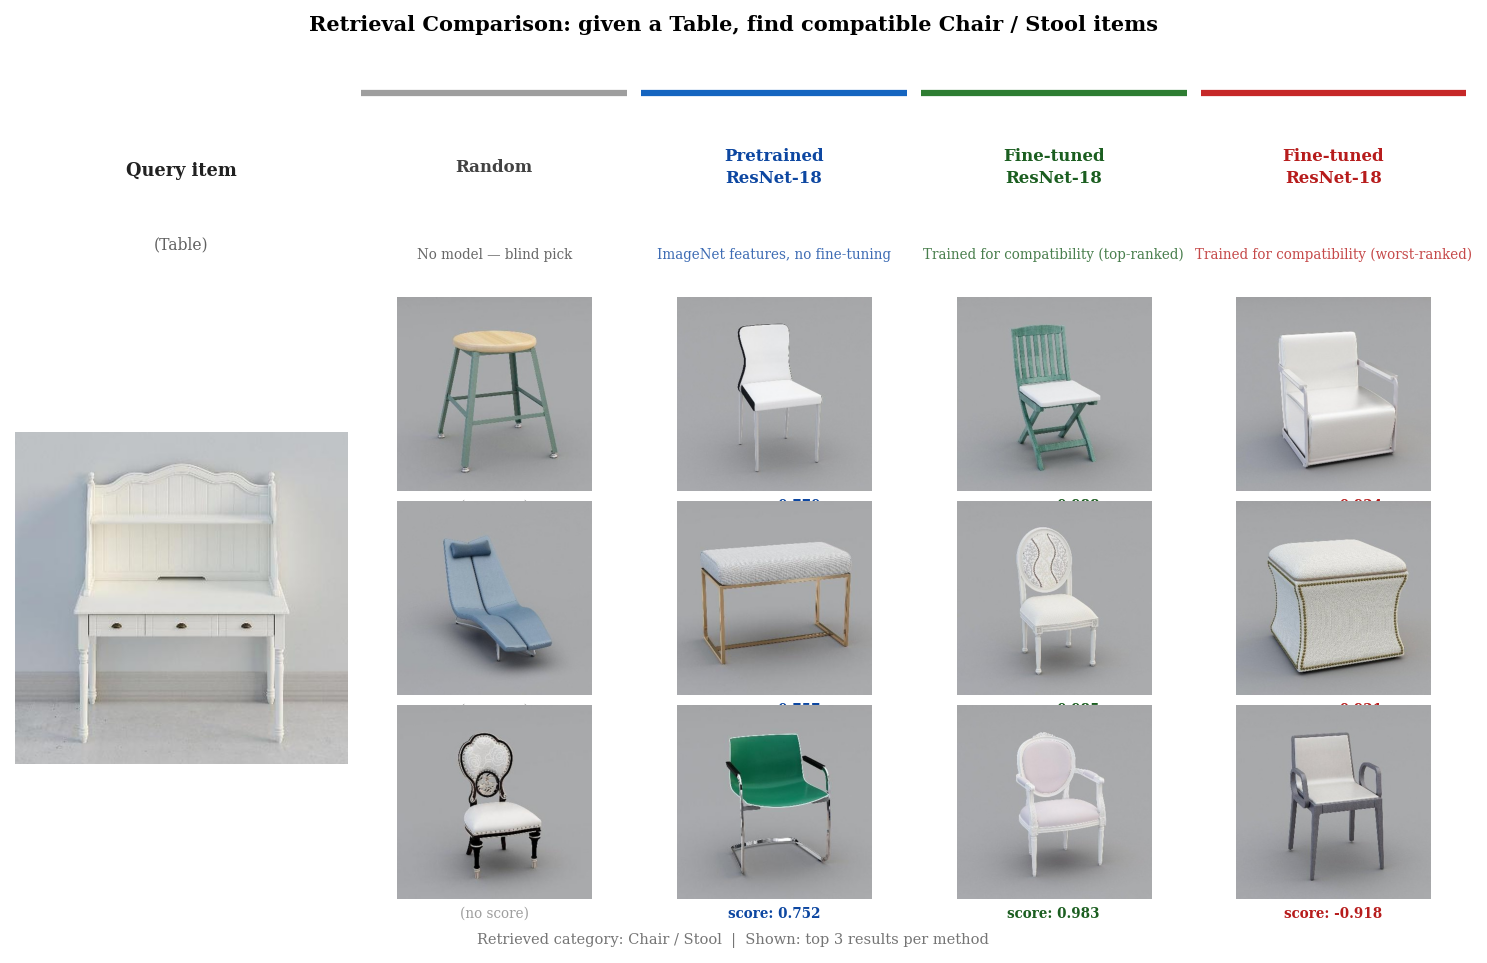

  Saved: fig1_grid__bedrooms__Table__to__Chair_Stool.png


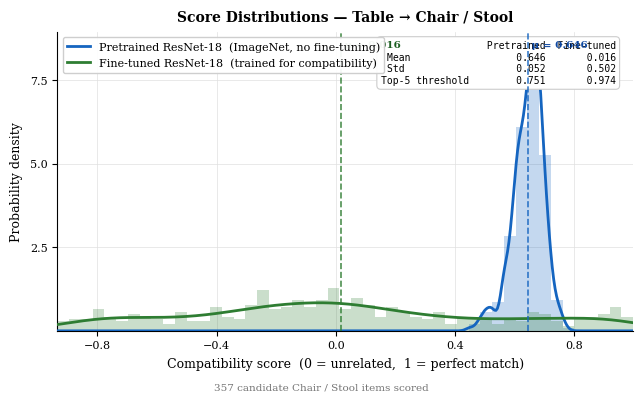

  Saved: fig2_dist__bedrooms__Table__to__Chair_Stool.png

Refinement → Table


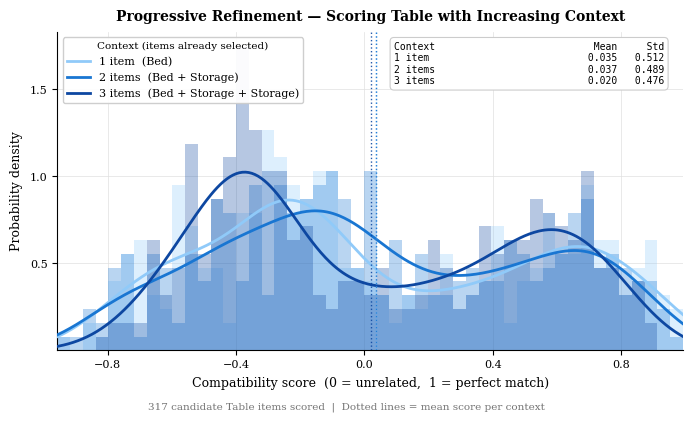

  Saved: fig3_refine__bedrooms__target_Table.png

Refinement → Chair / Stool


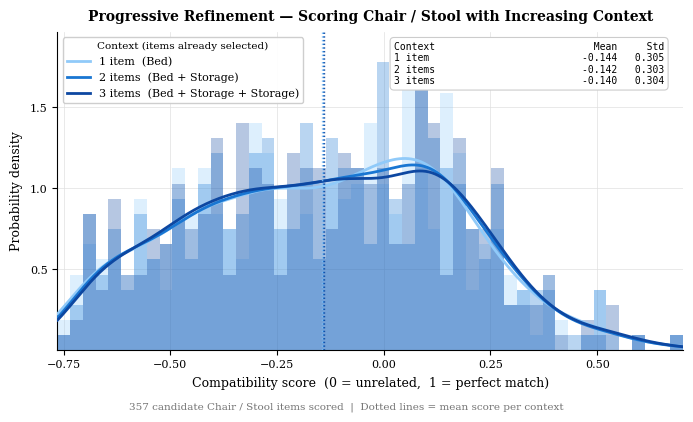

  Saved: fig3_refine__bedrooms__target_Chair_Stool.png

✓ All figures saved to: d:\Programing\thesis_v2_v3\data\thesis_figures\comparison


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Generate and save all figures
# ─────────────────────────────────────────────────────────────────────────────

def safe_name(cat: str) -> str:
    """Convert a category label to a filesystem-safe string (no / or spaces)."""
    return cat_label(cat).replace(" / ", "_").replace("/", "_").replace(" ", "_")


# --- Figure 1 & 2 scenarios (anchor index, target index in chain) ---
GRID_SCENARIOS = [
    (0, 1),   # Bed → Small Storage
    (0, 2),   # Bed → Large Storage
    (2, 3),   # Large Storage → Table
    (3, 4),   # Table → Chair / Stool
]

# --- Figure 3 refinement scenarios ---
# target_idx >= 2; uses chain[0..target_idx-1] as context.
REFINE_SCENARIOS = [
    3,   # target = Table,       context = Bed + Small Storage + Large Storage
    4,   # target = Chair/Stool, context = Bed + Small Storage + Large Storage + Table
]

N_ITEMS = 3   # items per column in Figure 1

# ── Figures 1 & 2 ────────────────────────────────────────────────────────────
for anchor_idx, target_idx in GRID_SCENARIOS:
    anchor_cat = chain[anchor_idx]
    target_cat = chain[target_idx]
    anchor     = retriever.get_random(anchor_cat, n=1)[0]
    stem       = f"{ROOM}__{safe_name(anchor_cat)}__to__{safe_name(target_cat)}"

    print(f"\n{cat_label(anchor_cat)} → {cat_label(target_cat)}")

    fig1 = make_grid_figure(anchor, target_cat, n=N_ITEMS)
    p1   = OUT_DIR / f"fig1_grid__{stem}.png"
    fig1.savefig(p1)
    plt.show()
    plt.close(fig1)
    print(f"  Saved: {p1.name}")

    fig2 = make_distribution_figure(anchor, target_cat)
    p2   = OUT_DIR / f"fig2_dist__{stem}.png"
    fig2.savefig(p2)
    plt.show()
    plt.close(fig2)
    print(f"  Saved: {p2.name}")

# ── Figure 3 — progressive refinement ────────────────────────────────────────
for t_idx in REFINE_SCENARIOS:
    print(f"\nRefinement → {cat_label(chain[t_idx])}")

    fig3 = make_refinement_figure(target_idx=t_idx, seed=42)
    p3   = OUT_DIR / f"fig3_refine__{ROOM}__target_{safe_name(chain[t_idx])}.png"
    fig3.savefig(p3)
    plt.show()
    plt.close(fig3)
    print(f"  Saved: {p3.name}")

print(f"\n✓ All figures saved to: {OUT_DIR}")